<a href="https://colab.research.google.com/github/nadiduno/hackatonAvanadeFiap/blob/main/palestra_rag_e_graphrag.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🧙‍♂️ RAG na prática

Neste notebook vamos construir, passo a passo, um **RAG** (*Retrieval-Augmented Generation*, ou Geração Aumentada por Recuperação).

### O que é RAG?

Um modelo de linguagem (LLM) só sabe o que aprendeu durante o treinamento. Ele não conhece os **seus** documentos.

O RAG resolve isso com uma ideia simples: **antes de responder, buscamos os textos mais relevantes e entregamos esses textos ao modelo junto com a pergunta**.

É como uma prova com consulta: em vez de responder de memória, o modelo responde lendo o trecho certo do material.

### As 3 etapas do RAG

| Etapa | O que acontece | Quando acontece |
| :--- | :--- | :--- |
| **1. Indexação** | Transformamos os textos em vetores e guardamos em um banco vetorial | Uma única vez |
| **2. Recuperação** | Buscamos os textos mais parecidos com a pergunta | A cada pergunta |
| **3. Geração** | O LLM responde usando os textos encontrados | A cada pergunta |


## ⚙️ Passo 1: Preparando o ambiente

### 1.1 Instalando as bibliotecas

O Google Colab já vem com várias bibliotecas instaladas, inclusive a base do LangChain (`langchain-core`). Por isso instalamos apenas o que falta:

- `langchain-groq`: conecta o LangChain ao LLM da Groq.
- `langchain-huggingface`: conecta o LangChain aos modelos de embeddings da HuggingFace.
- `sentence-transformers`: executa o modelo de embeddings. No Colab ele já está instalado, então o `pip` apenas confirma e segue em frente.

(Ahh.. O `-q` deixa a instalação silenciosa: se tudo der certo, nada aparece na tela.)

In [ ]:
!pip install -q langchain-groq langchain-huggingface sentence-transformers
print('Ufa, tudo certo por aqui ✅')

Ufa, tudo certo por aqui ✅


### 1.2 Configurando a chave da Groq

Para usar o LLM precisamos de uma chave de API da Groq. Você pode criar a sua gratuitamente em [console.groq.com/keys](https://console.groq.com/keys).

Uma chave é como uma senha: **nunca deve ficar escrita no notebook**. Por isso vamos guardá-la nos **Secrets** do Colab:

1. No menu lateral esquerdo do Colab, clique no ícone de chave 🔑 (**Secrets**).
2. Clique em **Adicionar novo secret**.
3. No campo **Nome**, escreva `GROQ`.
4. No campo **Valor**, cole a sua chave.
5. Ative a opção **Acesso ao notebook**. Sem isso, o notebook não consegue ler a chave.

Com o secret criado, importamos o `userdata`, a ferramenta do Colab que lê os Secrets.

In [ ]:
from google.colab import userdata

O `userdata.get` busca o secret pelo nome. Pedimos o secret chamado `GROQ` e guardamos o valor na variável `chave_groq`.

In [ ]:
chave_groq = userdata.get("GROQ")

Importamos o `os`, módulo do Python que conversa com o sistema operacional.

In [ ]:
import os

Guardamos a chave em uma **variável de ambiente** chamada `GROQ_API_KEY`.

A biblioteca da Groq procura a chave exatamente nesse lugar e com esse nome.

In [ ]:
os.environ["GROQ_API_KEY"] = chave_groq

## 📜 Passo 2: Carregando a base de conhecimento

Nossa base de conhecimento são 10 arquivos `.txt`. Cada arquivo conta um pedaço da história do Senhor dos Anéis.

Eles estão guardados em um repositório público no GitHub: [guilhermeonrails/data-senhor-dos-aneis](https://github.com/guilhermeonrails/data-senhor-dos-aneis). Assim não precisamos enviar nenhum arquivo manualmente.

### 2.1 Baixando os documentos do GitHub

O comando `git clone` copia o repositório inteiro para o nosso ambiente. Ele cria uma pasta chamada `data-senhor-dos-aneis`, e os textos ficam dentro dela, na pasta `data`.

> Se você executar esta célula uma segunda vez, vai aparecer um aviso dizendo que a pasta já existe. Pode ignorar: os arquivos já estão baixados.

In [ ]:
!git clone https://github.com/guilhermeonrails/data-senhor-dos-aneis

Cloning into 'data-senhor-dos-aneis'...
remote: Enumerating objects: 13, done.
remote: Counting objects: 100% (13/13), done.
remote: Compressing objects: 100% (12/12), done.
remote: Total 13 (delta 0), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (13/13), done.


Vamos conferir se os arquivos chegaram. O comando `ls` lista o conteúdo de uma pasta.

In [ ]:
!ls data-senhor-dos-aneis/data

doc_01_frodo_e_anel.txt		 doc_06_confronto_laracna.txt
doc_02_sam_lealdade.txt		 doc_07_sauron_anel.txt
doc_03_galadriel_lothlorien.txt  doc_08_isildur_narsil.txt
doc_04_frasco_de_earendil.txt	 doc_09_aragorn_rei.txt
doc_05_laracna_cirith_ungol.txt  doc_10_sociedade_do_anel.txt


### 2.2 Importando o `glob`

Agora vamos ler esses arquivos com Python. O `glob` encontra arquivos cujo nome segue um padrão.

In [ ]:
import glob

### 2.3 Encontrando os arquivos

O padrão `data-senhor-dos-aneis/data/doc_*.txt` significa: dentro da pasta `data` do repositório que baixamos, todo arquivo que começa com `doc_` e termina com `.txt`.

O `*` funciona como um coringa: aceita qualquer texto no lugar dele.

In [ ]:
caminhos = glob.glob("data-senhor-dos-aneis/data/doc_*.txt")

In [ ]:
caminhos

['data-senhor-dos-aneis/data/doc_07_sauron_anel.txt',
 'data-senhor-dos-aneis/data/doc_09_aragorn_rei.txt',
 'data-senhor-dos-aneis/data/doc_10_sociedade_do_anel.txt',
 'data-senhor-dos-aneis/data/doc_06_confronto_laracna.txt',
 'data-senhor-dos-aneis/data/doc_02_sam_lealdade.txt',
 'data-senhor-dos-aneis/data/doc_04_frasco_de_earendil.txt',
 'data-senhor-dos-aneis/data/doc_03_galadriel_lothlorien.txt',
 'data-senhor-dos-aneis/data/doc_01_frodo_e_anel.txt',
 'data-senhor-dos-aneis/data/doc_08_isildur_narsil.txt',
 'data-senhor-dos-aneis/data/doc_05_laracna_cirith_ungol.txt']

### 2.4 Ordenando os arquivos

O `glob` não garante a ordem dos arquivos. Usamos o `sorted` para colocá-los em ordem alfabética, do `doc_01` ao `doc_10`.

In [ ]:
caminhos = sorted(caminhos)

In [ ]:
caminhos

['data-senhor-dos-aneis/data/doc_01_frodo_e_anel.txt',
 'data-senhor-dos-aneis/data/doc_02_sam_lealdade.txt',
 'data-senhor-dos-aneis/data/doc_03_galadriel_lothlorien.txt',
 'data-senhor-dos-aneis/data/doc_04_frasco_de_earendil.txt',
 'data-senhor-dos-aneis/data/doc_05_laracna_cirith_ungol.txt',
 'data-senhor-dos-aneis/data/doc_06_confronto_laracna.txt',
 'data-senhor-dos-aneis/data/doc_07_sauron_anel.txt',
 'data-senhor-dos-aneis/data/doc_08_isildur_narsil.txt',
 'data-senhor-dos-aneis/data/doc_09_aragorn_rei.txt',
 'data-senhor-dos-aneis/data/doc_10_sociedade_do_anel.txt']

Vamos conferir quantos arquivos foram encontrados. O esperado é **10**.

In [ ]:
len(caminhos)

10

### 2.5 Lendo um arquivo

Antes de ler todos, vamos ler apenas o primeiro para entender cada etapa.

Começamos pegando o primeiro caminho da lista. Em Python, a primeira posição é a `0`.

In [ ]:
primeiro_caminho = caminhos[0]

In [ ]:
primeiro_caminho

'data-senhor-dos-aneis/data/doc_01_frodo_e_anel.txt'

Abrimos o arquivo com `open`:

- `"r"` significa *read* (leitura): só vamos ler, sem alterar nada.
- `encoding="utf-8"` garante que os acentos do português sejam lidos corretamente.

In [ ]:
arquivo = open(primeiro_caminho, "r", encoding="utf-8")

O `read` lê todo o conteúdo do arquivo e devolve como texto.

In [ ]:
texto = arquivo.read()

In [ ]:
texto

'Frodo Bolseiro é um hobbit do Condado que herdou o Anel Único de seu tio Bilbo Bolseiro. Frodo assumiu a missão de levar o Anel até a Montanha da Perdição em Mordor para destruí-lo.'

Depois de ler, fechamos o arquivo para liberar o recurso.

In [ ]:
arquivo.close()

Este é o conteúdo do primeiro documento:

### 2.6 Lendo todos os arquivos

Agora repetimos os mesmos passos para os 10 arquivos, usando um `for`.

Cada texto lido é adicionado à lista `textos`. O `strip` remove espaços e quebras de linha que sobram no começo e no fim.

In [ ]:
# Lista vazia que vai guardar o texto de cada arquivo
textos = []

# Repete os passos abaixo para cada caminho da lista
for caminho in caminhos:
    # Abre o arquivo para leitura
    arquivo = open(caminho, "r", encoding="utf-8")
    # Lê todo o conteúdo
    texto = arquivo.read()
    # Fecha o arquivo
    arquivo.close()
    # Remove espaços e quebras de linha das pontas
    texto = texto.strip()
    # Guarda o texto na lista
    textos.append(texto)

Conferindo: devemos ter 10 textos na lista.

In [ ]:
len(textos)

10

> **E o *chunking*?** Em projetos reais os documentos são longos (PDFs, artigos) e precisam ser cortados em pedaços menores, chamados *chunks*, antes da indexação. Aqui cada arquivo tem apenas uma ou duas frases, então cada arquivo já é um *chunk* pronto.

## 🔢 Passo 3: Embeddings — transformando texto em números

O computador não entende o significado das palavras. Para comparar textos, transformamos cada um em uma lista de números chamada **embedding** (ou vetor).

A ideia central: **textos com significados parecidos geram vetores parecidos**. Assim, "comparar significados" vira "comparar números".

### 3.1 Importando a classe de embeddings

In [ ]:
from langchain_huggingface import HuggingFaceEmbeddings

### 3.2 Carregando o modelo de embeddings

Vamos usar o `all-MiniLM-L6-v2`, um modelo pequeno, gratuito e que roda na própria máquina.

Na primeira execução ele é baixado da internet, então esta célula pode demorar alguns segundos.

> Durante o download pode aparecer um aviso sobre `HF_TOKEN`. Não é um erro: o token é opcional e o modelo é baixado normalmente sem ele.

In [ ]:
embeddings_model = HuggingFaceEmbeddings(model_name="sentence-transformers/all-MiniLM-L6-v2")

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/350 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

### 3.3 Vendo um embedding de perto

Vamos transformar uma frase em vetor para ver o que acontece. O método `embed_query` recebe um texto e devolve o vetor dele.

In [ ]:
vetor = embeddings_model.embed_query("Frodo Bolseiro é um hobbit")

Qual é o tamanho desse vetor?

In [ ]:
len(vetor)

384

São **384 números**. Esse tamanho é fixo: uma palavra ou um parágrafo inteiro sempre viram 384 números neste modelo.

Vamos olhar os 5 primeiros:

In [ ]:
vetor[:5]

[0.004629244562238455,
 0.07263851910829544,
 -0.05632121488451958,
 0.017042919993400574,
 0.015413273125886917]

Sozinhos, esses números não dizem nada para nós. O valor deles aparece na **comparação**: quanto mais próximos dois vetores, mais parecido é o significado dos textos.

## 🗄️ Passo 4: Indexação — guardando os vetores no banco vetorial

Agora vamos transformar os 10 textos em vetores e guardá-los em um **banco vetorial**. Usaremos o `InMemoryVectorStore`, um banco vetorial que já vem dentro do LangChain e guarda tudo na memória. Ele é ideal para aprender e para bases pequenas como a nossa.

### 4.1 Importando a classe `Document`

O LangChain não trabalha com textos soltos. Ele usa um objeto chamado `Document`, que guarda o texto no campo `page_content`.

In [ ]:
from langchain_core.documents import Document

### 4.2 Convertendo os textos em `Document`

Para cada texto da lista, criamos um `Document` e guardamos na lista `docs`.

In [ ]:
# Lista vazia que vai guardar os objetos Document
docs = []

# Repete os passos abaixo para cada texto
for texto in textos:
    # Cria um Document com o texto dentro
    doc = Document(page_content=texto)
    # Guarda o Document na lista
    docs.append(doc)

Vamos ver como ficou o primeiro `Document`:

In [ ]:
docs[0]

Document(metadata={}, page_content='Frodo Bolseiro é um hobbit do Condado que herdou o Anel Único de seu tio Bilbo Bolseiro. Frodo assumiu a missão de levar o Anel até a Montanha da Perdição em Mordor para destruí-lo.')

### 4.3 Importando o banco vetorial

In [ ]:
from langchain_core.vectorstores import InMemoryVectorStore

### 4.4 Criando o banco vetorial

Esta única linha faz duas coisas:

1. Usa o `embeddings_model` para transformar cada um dos 10 documentos em vetor.
2. Guarda os 10 vetores (e seus textos) dentro do banco vetorial.

In [ ]:
vectorstore = InMemoryVectorStore.from_documents(docs, embeddings_model)

Conferindo quantos vetores estão guardados no banco. O esperado é **10**, um para cada documento.

In [ ]:
len(vectorstore.store)

10

✅ A **indexação** está pronta. Ela é feita uma única vez. A partir daqui, tudo o que fazemos se repete a cada pergunta.

## 🔍 Passo 5: Recuperação — buscando os textos mais parecidos

Na recuperação, a pergunta do usuário passa pelo mesmo caminho dos documentos: ela vira um vetor. Depois o banco vetorial encontra os vetores dos documentos que estão **mais próximos** do vetor da pergunta.

### 5.1 Definindo uma pergunta

In [ ]:
pergunta = "Qual objeto místico Galadriel presenteou a Frodo Bolseiro?"

### 5.2 Buscando com pontuação

O método `similarity_search_with_score` devolve os documentos mais próximos da pergunta junto com a **similaridade** de cada um.

O parâmetro `k=2` pede os **2** documentos mais próximos.

In [ ]:
resultados = vectorstore.similarity_search_with_score(pergunta, k=2)

Cada resultado é um par: o documento e a similaridade dele com a pergunta.

A similaridade é um número que vai até 1. **Quanto mais perto de 1, mais parecido** o documento é com a pergunta.

In [ ]:
# Percorre cada par (documento, similaridade) encontrado
for doc, similaridade in resultados:
    # Mostra a similaridade entre o documento e a pergunta
    print("Similaridade:", similaridade)
    # Mostra o texto do documento
    print("Texto:", doc.page_content)
    # Linha em branco para separar os resultados
    print()

Similaridade: 0.6761630584501774
Texto: Galadriel presenteou Frodo Bolseiro com o Frasco de Eärendil, um cristal mágico contendo a luz da Estrela Vespertina que brilha mesmo nas trevas mais profundas.

Similaridade: 0.6692252923223856
Texto: Frodo Bolseiro é um hobbit do Condado que herdou o Anel Único de seu tio Bilbo Bolseiro. Frodo assumiu a missão de levar o Anel até a Montanha da Perdição em Mordor para destruí-lo.



Repare que em nenhum momento procuramos por palavras exatas. A busca foi feita pelo **significado**, comparando vetores. Isso se chama **busca semântica**.

### 5.3 Criando o retriever

O **retriever** é a forma padrão do LangChain de fazer essa busca. Ele faz a mesma coisa que vimos acima, mas devolve só os documentos, sem a similaridade.

O `search_kwargs={"k": 2}` configura o retriever para sempre trazer os 2 documentos mais próximos.

In [ ]:
retriever = vectorstore.as_retriever(search_kwargs={"k": 2})

### 5.4 Usando o retriever

O método `invoke` recebe a pergunta e devolve a lista de documentos recuperados.

In [ ]:
docs_recuperados = retriever.invoke(pergunta)

Devem ser 2 documentos, pois definimos `k=2`.

In [ ]:
len(docs_recuperados)

2

### 5.5 Montando o contexto

O LLM recebe texto, não uma lista de objetos. Por isso juntamos o texto dos documentos recuperados em uma única variável, chamada `contexto`.

Vamos somando o texto de cada documento, com uma quebra de linha (`\n`) entre eles.

In [ ]:
# Começa com um texto vazio
contexto = ""

# Repete os passos abaixo para cada documento recuperado
for doc in docs_recuperados:
    # Acrescenta o texto do documento ao contexto
    contexto = contexto + doc.page_content
    # Acrescenta uma quebra de linha para separar do próximo
    contexto = contexto + "\n"

Este é o contexto que será entregue ao LLM:

In [ ]:
print(contexto)

Galadriel presenteou Frodo Bolseiro com o Frasco de Eärendil, um cristal mágico contendo a luz da Estrela Vespertina que brilha mesmo nas trevas mais profundas.
Frodo Bolseiro é um hobbit do Condado que herdou o Anel Único de seu tio Bilbo Bolseiro. Frodo assumiu a missão de levar o Anel até a Montanha da Perdição em Mordor para destruí-lo.



## 🤖 Passo 6: Geração — o LLM responde usando o contexto

Já temos a pergunta e o contexto. Falta a última peça: pedir ao LLM que responda **usando apenas esse contexto**.

### 6.1 Importando o modelo da Groq

In [ ]:
from langchain_groq import ChatGroq

### 6.2 Criando o LLM

- `model`: qual modelo usar. O `openai/gpt-oss-120b` é rápido e de boa qualidade.
- `temperature=0.0`: controla a criatividade. Com `0`, o modelo fica o mais previsível possível, o que é o ideal quando queremos respostas fiéis aos documentos.

In [ ]:
llm = ChatGroq(model="openai/gpt-oss-120b", temperature=0.0)

### 6.3 Importando o modelo de prompt

In [ ]:
from langchain_core.prompts import ChatPromptTemplate

### 6.4 Escrevendo o texto do prompt

O prompt é a instrução que enviamos ao LLM. Ele tem dois espaços em branco, marcados com chaves:

- `{contexto}`: onde entram os textos recuperados.
- `{pergunta}`: onde entra a pergunta do usuário.

A frase **"usando apenas o contexto fornecido"** é o coração do RAG: ela pede que o modelo responda com base nos nossos documentos, e não de memória.

In [ ]:
texto_do_prompt = """
Você é um assistente objetivo especialista em Senhor dos Anéis.
Responda à pergunta do usuário de forma DIRETA, CURTA e OBJETIVA, usando apenas o contexto fornecido.
Se a resposta não estiver no contexto, diga que não sabe.

Contexto:
{contexto}

Pergunta: {pergunta}
Resposta Curta:
"""

### 6.5 Criando o modelo de prompt

O `ChatPromptTemplate` transforma esse texto em um molde reutilizável, capaz de preencher os espaços `{contexto}` e `{pergunta}`.

In [ ]:
prompt_rag = ChatPromptTemplate.from_template(texto_do_prompt)

### 6.6 Preenchendo o prompt

Entregamos um dicionário com o valor de cada espaço em branco. O resultado é o prompt completo, pronto para ser enviado.

In [ ]:
prompt_preenchido = prompt_rag.invoke({"contexto": contexto, "pergunta": pergunta})

Vamos ver exatamente o que o LLM vai receber. Repare que o contexto e a pergunta já estão no lugar das chaves.

In [ ]:
print(prompt_preenchido.to_string())

Human: 
Você é um assistente objetivo especialista em Senhor dos Anéis.
Responda à pergunta do usuário de forma DIRETA, CURTA e OBJETIVA, usando apenas o contexto fornecido.
Se a resposta não estiver no contexto, diga que não sabe.

Contexto:
Galadriel presenteou Frodo Bolseiro com o Frasco de Eärendil, um cristal mágico contendo a luz da Estrela Vespertina que brilha mesmo nas trevas mais profundas.
Frodo Bolseiro é um hobbit do Condado que herdou o Anel Único de seu tio Bilbo Bolseiro. Frodo assumiu a missão de levar o Anel até a Montanha da Perdição em Mordor para destruí-lo.


Pergunta: Qual objeto místico Galadriel presenteou a Frodo Bolseiro?
Resposta Curta:



### 6.7 Enviando o prompt ao LLM

O `invoke` envia o prompt para a Groq e espera a resposta.

In [ ]:
resposta = llm.invoke(prompt_preenchido)

### 6.8 Lendo a resposta

A resposta vem em um objeto com várias informações. O texto escrito pelo modelo fica no campo `content`.

In [ ]:
resposta

AIMessage(content='Frasco de Eärendil.', additional_kwargs={'reasoning_content': 'The user wants a direct short answer: "Frasco de Eärendil". Provide that.'}, response_metadata={'token_usage': {'completion_tokens': 38, 'prompt_tokens': 248, 'total_tokens': 286, 'completion_time': 0.081349486, 'completion_tokens_details': {'reasoning_tokens': 21}, 'prompt_time': 0.076135429, 'prompt_tokens_details': None, 'queue_time': 0.158357414, 'total_time': 0.157484915}, 'model_name': 'openai/gpt-oss-120b', 'system_fingerprint': 'fp_02b0d31eca', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--01a118b5-5bc4-7942-8aa7-82e87d1a0220-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 248, 'output_tokens': 38, 'total_tokens': 286, 'output_token_details': {'reasoning': 21}})

🎉 Esse é o RAG completo: **recuperamos** os textos relevantes e o LLM **gerou** a resposta a partir deles.

In [ ]:
resposta.content

'Frasco de Eärendil.'

## 🧩 Passo 7: Juntando tudo em uma função

Para não repetir todas essas células a cada pergunta, vamos reunir tudo em uma única função, a `executar_rag`. Ela faz quatro coisas:

1. **Pede a pergunta** ao usuário, com o `input`.
2. **Recupera** os documentos mais parecidos e monta o contexto (Passo 5).
3. **Gera** a resposta com o LLM (Passo 6).
4. **Mostra** a resposta e as **fontes**: o nome do arquivo e o trecho de cada documento entregue ao LLM.

Mostrar as fontes é uma das grandes vantagens do RAG. Com elas, qualquer pessoa pode conferir se a resposta está mesmo apoiada nos documentos.

As linhas de recuperação e geração são exatamente as mesmas que executamos acima.

In [ ]:
def executar_rag(pergunta=None):
    # Se não recebeu uma pergunta, pede pelo input
    if pergunta is None:
        pergunta = input("Digite sua pergunta: ")

    # Recuperação
    docs_recuperados = retriever.invoke(pergunta)

    # Junta o conteúdo dos documentos
    contexto = ""
    for doc in docs_recuperados:
        contexto += doc.page_content + "\n"

    # Preenche o prompt
    prompt_preenchido = prompt_rag.invoke({
        "contexto": contexto,
        "pergunta": pergunta
    })

    # Geração
    resposta = llm.invoke(prompt_preenchido)

    # Exibe a resposta
    print()
    print("🤖 RESPOSTA:")
    print(resposta.content)

In [ ]:
# executar_rag()

In [ ]:
pergunta = "A Senhora de Lothlórien deu um presente que foi usado contra qual criatura?"
executar_rag(pergunta)


🤖 RESPOSTA:
Não sei.


## 💡 Conclusão

### O que construímos

| Etapa | O que fizemos | Código principal |
| :--- | :--- | :--- |
| **Indexação** | Transformamos 10 textos em vetores e guardamos no banco vetorial | `InMemoryVectorStore.from_documents(docs, embeddings_model)` |
| **Recuperação** | Buscamos os 2 textos mais próximos da pergunta | `retriever.invoke(pergunta)` |
| **Geração** | O LLM respondeu usando apenas esses textos | `llm.invoke(prompt_preenchido)` |

### Pontos fortes do RAG

- Simples e barato de montar: basta gerar os embeddings.
- Excelente para **perguntas locais**, com resposta em um único trecho.
- A resposta vem dos seus documentos, o que reduz as invenções do modelo.

### Limitação

- O RAG enxerga cada documento como um pedaço **isolado**. Ele não sabe que Galadriel, o Frasco e Laracna fazem parte da mesma história.
- Em perguntas que exigem conectar vários documentos, parte da informação pode não ser recuperada.

É exatamente essa limitação que o **GraphRAG** resolve, ao guardar também as **relações** entre as entidades.

# 🕸️ Parte 2: GraphRAG

Na Parte 1 vimos que o RAG tradicional enxerga cada documento como um pedaço **isolado**. Agora vamos construir um **GraphRAG**, que guarda também as **ligações** entre as informações.

### O que é um grafo?

Um grafo é um desenho feito de **bolinhas ligadas por setas**.

Pense em um mapa de metrô: as estações são as bolinhas e os trilhos são as ligações entre elas. Ou em uma árvore genealógica: as pessoas são as bolinhas e o parentesco é a ligação.

Em um grafo, cada parte tem um nome:

| Nome | O que é | Exemplo |
| :--- | :--- | :--- |
| **Nó** | Uma bolinha. Representa uma "coisa": personagem, lugar, objeto ou grupo | `Galadriel` |
| **Aresta** | Uma seta que liga dois nós. Representa a relação entre eles | `presenteou` |
| **Tripla** | Dois nós e a seta entre eles. É um fato completo | `Galadriel -> presenteou -> Frodo` |

Quando juntamos muitas triplas, as bolinhas repetidas se encontram e os fatos ficam **conectados**:

```
Frasco de Eärendil <- deu <- Galadriel -> é senhora de -> Lothlórien
```

Repare: um fato veio de um documento e o outro fato veio de outro documento. No grafo, eles se encontram no nó `Galadriel`. É isso que o RAG tradicional não consegue fazer.

### As 3 etapas do GraphRAG

| Etapa | RAG tradicional | GraphRAG |
| :--- | :--- | :--- |
| **1. Indexação** | Transforma os textos em vetores | Usa o LLM para extrair as triplas e monta o grafo |
| **2. Recuperação** | Busca os textos mais parecidos com a pergunta | Acha as entidades da pergunta no grafo e caminha pelas setas |
| **3. Geração** | O LLM responde lendo os textos | O LLM responde lendo as relações |

Vamos usar a **mesma base de dados** (a lista `textos`, com os 10 documentos) e o **mesmo LLM** da Parte 1.

## ❌ Passo 8: A pergunta que o RAG tradicional não responde

### 8.1 Definindo a pergunta

Vamos guardar em uma variável uma pergunta que exige **cruzar dois documentos**.

In [ ]:
pergunta_dificil = "Em qual reino vive quem deu o Frasco de Eärendil a Frodo?"

A resposta correta é **Lothlórien**. Para chegar nela é preciso juntar dois fatos, que estão em arquivos diferentes:

- `doc_04`: **Galadriel** deu o Frasco de Eärendil a Frodo.
- `doc_03`: Galadriel é a Senhora Elfa de **Lothlórien**.

### 8.2 O que o RAG tradicional recupera?

Vamos pedir ao retriever da Parte 1 os documentos mais parecidos com essa pergunta.

In [ ]:
docs_da_pergunta_dificil = retriever.invoke(pergunta_dificil)

E mostrar o texto de cada documento recuperado:

In [ ]:
# Percorre cada documento recuperado
for doc in docs_da_pergunta_dificil:
    # Mostra o texto do documento
    print(doc.page_content)
    # Linha em branco para separar os documentos
    print()

Galadriel presenteou Frodo Bolseiro com o Frasco de Eärendil, um cristal mágico contendo a luz da Estrela Vespertina que brilha mesmo nas trevas mais profundas.

No desfiladeiro de Cirith Ungol, Frodo e Sam utilizaram a luz do Frasco de Eärendil dado por Galadriel para cegar e repelir a aranha Laracna, conseguindo sobreviver e avançar para Mordor.



Leia os textos acima. O documento que diz que Galadriel é a Senhora de **Lothlórien** não foi recuperado.

O motivo: a pergunta não cita "Galadriel" nem "Lothlórien". O retriever busca textos **parecidos com a pergunta**, e o texto que tem a resposta não se parece com ela.

### 8.3 Fazendo a pergunta ao RAG tradicional

In [ ]:
executar_rag(pergunta_dificil)


🤖 RESPOSTA:
Lothlórien.


Sem o documento certo no contexto, o RAG tradicional não tem como responder com base nos nossos textos.

> Se o modelo responder "Lothlórien" mesmo assim, ele usou a própria **memória**, pois a história é famosa. Com documentos privados de uma empresa, que o modelo nunca viu, isso não aconteceria.

## ✂️ Passo 9: Indexação — extraindo as triplas com o LLM

Para montar o grafo precisamos transformar cada texto em **triplas**. Quem faz esse trabalho é o próprio LLM: ele lê o texto e devolve os fatos no formato `sujeito -> relação -> objeto`.

### 9.1 Escrevendo o prompt de extração

O prompt explica ao LLM o que é uma tripla e define algumas regras. As regras servem para que a mesma entidade tenha **sempre o mesmo nome**. Se um texto gerar `Frodo` e outro gerar `Frodo Bolseiro`, o grafo terá duas bolinhas diferentes e os fatos não vão se conectar.

Pedimos a resposta em **JSON**, um formato de texto que o Python transforma facilmente em lista.

As chaves duplas `{{ }}` no exemplo são necessárias porque as chaves simples já são usadas para marcar o espaço em branco `{texto}`.

In [ ]:
texto_do_prompt_triplas = """
Extraia do texto abaixo as triplas de conhecimento no formato (sujeito, relação, objeto).

Regras:
- Sujeito e objeto devem ser nomes curtos de personagens, lugares, objetos ou grupos.
- Use sempre o nome mais curto e conhecido. Exemplo: escreva "Frodo", e nunca "Frodo Bolseiro".
- Cada tripla tem apenas um sujeito e um objeto. Se o texto diz "Frodo e Sam", crie uma tripla para cada um.
- A relação deve ser um verbo ou uma expressão curta. Exemplos: "herdou", "é amigo de".

Responda APENAS com uma lista JSON, sem nenhum texto antes ou depois, neste formato:
[{{"sujeito": "Gandalf", "relacao": "é um", "objeto": "mago"}}]

Texto: {texto}
"""

### 9.2 Criando o modelo de prompt

Assim como na Parte 1, o `ChatPromptTemplate` transforma o texto em um molde reutilizável.

In [ ]:
prompt_triplas = ChatPromptTemplate.from_template(texto_do_prompt_triplas)

### 9.3 Testando com um único texto

Antes de processar os 10 documentos, vamos extrair as triplas de apenas um, para entender cada etapa.

Pegamos o primeiro texto da lista:

In [ ]:
primeiro_texto = textos[0]

In [ ]:
primeiro_texto

'Frodo Bolseiro é um hobbit do Condado que herdou o Anel Único de seu tio Bilbo Bolseiro. Frodo assumiu a missão de levar o Anel até a Montanha da Perdição em Mordor para destruí-lo.'

Preenchemos o prompt, colocando o texto no espaço `{texto}`:

In [ ]:
prompt_triplas_preenchido = prompt_triplas.invoke({"texto": primeiro_texto})

Enviamos o prompt ao LLM:

In [ ]:
resposta_triplas = llm.invoke(prompt_triplas_preenchido)

E vemos o que o LLM escreveu:

In [ ]:
resposta_triplas.content

'[{"sujeito":"Frodo","relacao":"é","objeto":"hobbit"},{"sujeito":"Frodo","relacao":"é de","objeto":"Condado"},{"sujeito":"Frodo","relacao":"herdou","objeto":"Anel"},{"sujeito":"Bilbo","relacao":"é tio de","objeto":"Frodo"},{"sujeito":"Frodo","relacao":"assumiu missão de levar","objeto":"Anel"},{"sujeito":"Anel","relacao":"destina‑se a","objeto":"Montanha da Perdição"},{"sujeito":"Montanha da Perdição","relacao":"está em","objeto":"Mordor"},{"sujeito":"Frodo","relacao":"destruirá","objeto":"Anel"}]'

### 9.4 Transformando a resposta em uma lista do Python

O que o LLM devolveu ainda é apenas um **texto**. Para usar as triplas no código, precisamos convertê-lo em uma lista de verdade.

O `JsonOutputParser` faz essa conversão.

In [ ]:
from langchain_core.output_parsers import JsonOutputParser

In [ ]:
parser = JsonOutputParser()

O `invoke` do parser recebe a resposta do LLM e devolve uma lista. Cada item da lista é uma tripla, com as chaves `sujeito`, `relacao` e `objeto`.

In [ ]:
triplas_do_primeiro_texto = parser.invoke(resposta_triplas)

In [ ]:
triplas_do_primeiro_texto

[{'sujeito': 'Frodo', 'relacao': 'é', 'objeto': 'hobbit'},
 {'sujeito': 'Frodo', 'relacao': 'é de', 'objeto': 'Condado'},
 {'sujeito': 'Frodo', 'relacao': 'herdou', 'objeto': 'Anel'},
 {'sujeito': 'Bilbo', 'relacao': 'é tio de', 'objeto': 'Frodo'},
 {'sujeito': 'Frodo', 'relacao': 'assumiu missão de levar', 'objeto': 'Anel'},
 {'sujeito': 'Anel',
  'relacao': 'destina‑se a',
  'objeto': 'Montanha da Perdição'},
 {'sujeito': 'Montanha da Perdição', 'relacao': 'está em', 'objeto': 'Mordor'},
 {'sujeito': 'Frodo', 'relacao': 'destruirá', 'objeto': 'Anel'}]

Um único texto virou vários fatos organizados.

### 9.5 Extraindo as triplas de todos os textos

Agora repetimos os mesmos passos para os 10 documentos, com um `for`. Todas as triplas vão para uma única lista, chamada `triplas`.

Esta célula faz **uma chamada ao LLM para cada documento**, por isso demora alguns segundos.

In [ ]:
# Lista vazia que vai guardar as triplas de todos os textos
triplas = []

# Repete os passos abaixo para cada texto
for texto in textos:
    # Preenche o prompt com o texto
    prompt_triplas_preenchido = prompt_triplas.invoke({"texto": texto})
    # Envia o prompt ao LLM
    resposta_triplas = llm.invoke(prompt_triplas_preenchido)
    # Transforma a resposta em uma lista de triplas
    triplas_do_texto = parser.invoke(resposta_triplas)
    # Guarda cada tripla desse texto na lista geral
    for tripla in triplas_do_texto:
        triplas.append(tripla)

Quantas triplas foram extraídas no total?

In [ ]:
len(triplas)

61

Vamos ler todas elas, uma por linha:

In [ ]:
# Percorre cada tripla extraída
for tripla in triplas:
    # Mostra a tripla no formato sujeito -> relação -> objeto
    print(tripla["sujeito"], "->", tripla["relacao"], "->", tripla["objeto"])

Frodo -> é -> hobbit
Frodo -> é de -> Condado
Frodo -> herdou -> Anel Único
Bilbo -> é tio de -> Frodo
Frodo -> assumiu -> missão
Frodo -> levou -> Anel Único
Anel Único -> vai para -> Montanha da Perdição
Montanha da Perdição -> está em -> Mordor
Frodo -> destruir -> Anel Único
Sam -> é amigo de -> Frodo
Sam -> é jardineiro de -> Frodo
Sam -> acompanha -> Frodo
Sam -> previne -> Frodo
Galadriel -> é senhora de -> Lothlórien
Galadriel -> guardiã de -> Nenya
Galadriel -> acolheu -> Sociedade
Galadriel -> presenteou -> Frodo
Galadriel -> deu -> Frasco
Frasco -> é -> cristal
cristal -> contém -> luz
luz -> pertence a -> Estrela
Estrela -> brilha -> trevas
Laracna -> é -> aranha
Laracna -> é -> gigante
Laracna -> é -> monstro
Laracna -> habita -> Cirith Ungol
Laracna -> está na fronteira de -> Mordor
Laracna -> devora -> viajantes
viajantes -> tentam entrar no reino de -> Sauron
Frodo -> usou -> Frasco
Sam -> usou -> Frasco
Galadriel -> deu -> Frasco
Luz -> cegou -> Laracna
Luz -> repeliu 

> O LLM pode escrever as triplas de um jeito um pouco diferente a cada execução. Isso é normal. O importante é que os nomes das entidades se repitam entre as triplas, pois é a repetição que conecta os fatos.

## 🏗️ Passo 10: Indexação — construindo o grafo

Com as triplas em mãos, vamos montar o grafo. Usaremos a biblioteca **NetworkX**, que já vem instalada no Colab.

### 10.1 Importando o NetworkX

O apelido `nx` é o nome que todo mundo usa para essa biblioteca.

In [ ]:
import networkx as nx

### 10.2 Criando um grafo vazio

O `DiGraph` é um grafo **direcionado**: as ligações são setas, com origem e destino.

A direção importa. `Galadriel -> presenteou -> Frodo` é diferente de `Frodo -> presenteou -> Galadriel`.

In [ ]:
grafo = nx.DiGraph()

### 10.3 Adicionando as triplas ao grafo

Para cada tripla, o `add_edge` cria uma seta saindo do `sujeito` e chegando no `objeto`. O texto da relação fica guardado dentro da seta.

Não precisamos criar as bolinhas antes: se o nó ainda não existe, o `add_edge` cria. Se **já existe**, ele reaproveita. É esse reaproveitamento que conecta os fatos de documentos diferentes.

In [ ]:
# Repete os passos abaixo para cada tripla
for tripla in triplas:
    # Pega o sujeito da tripla
    sujeito = tripla["sujeito"]
    # Pega a relação da tripla
    relacao = tripla["relacao"]
    # Pega o objeto da tripla
    objeto = tripla["objeto"]
    # Cria a seta sujeito -> objeto e guarda a relação dentro dela
    grafo.add_edge(sujeito, objeto, relacao=relacao)

Quantos nós (bolinhas) o grafo tem?

In [ ]:
grafo.number_of_nodes()

42

E quantas arestas (setas)?

O número pode ser menor que o de triplas. Entre dois nós, no mesmo sentido, o grafo guarda uma única seta. Se duas triplas ligam os mesmos nós, a segunda substitui a primeira.

In [ ]:
grafo.number_of_edges()

53

Estes são os nós do grafo, ou seja, todas as entidades que o LLM encontrou nos 10 documentos:

In [ ]:
list(grafo.nodes)

['Frodo',
 'hobbit',
 'Condado',
 'Anel Único',
 'Bilbo',
 'missão',
 'Montanha da Perdição',
 'Mordor',
 'Sam',
 'Galadriel',
 'Lothlórien',
 'Nenya',
 'Sociedade',
 'Frasco',
 'cristal',
 'luz',
 'Estrela',
 'trevas',
 'Laracna',
 'aranha',
 'gigante',
 'monstro',
 'Cirith Ungol',
 'viajantes',
 'Sauron',
 'Luz',
 'Cirith',
 'Anel',
 'Montanha',
 'poder',
 'essência',
 'Isildur',
 'Gondor',
 'Narsil',
 'Aragorn',
 'Povos Livres',
 'Merry',
 'Pippin',
 'Gandalf',
 'Boromir',
 'Legolas',
 'Gimli']

✅ A **indexação** do GraphRAG está pronta. Assim como no RAG tradicional, ela é feita uma única vez.

## 🎨 Passo 11: Desenhando o grafo

Uma das vantagens do grafo é que podemos **olhar** para ele. Vamos desenhá-lo com o **Matplotlib**, que também já vem instalado no Colab.

### 11.1 Importando o Matplotlib

In [ ]:
import matplotlib.pyplot as plt

### 11.2 Criando uma função de desenho

Vamos desenhar mais de uma vez, então colocamos o código de desenho dentro de uma função. Ela recebe um grafo e mostra a imagem.

O desenho é feito em camadas: primeiro as bolinhas, depois os nomes, depois as setas e por fim o texto de cada seta.

O `spring_layout` calcula a posição de cada bolinha no desenho. O `seed=42` faz o desenho sair sempre igual.

In [ ]:
def desenhar_grafo(grafo_para_desenhar):
    # Define o tamanho da imagem
    plt.figure(figsize=(18, 12))

    # Calcula a posição de cada nó no desenho
    posicoes = nx.spring_layout(grafo_para_desenhar, k=3, seed=42)

    # Desenha os nós (bolinhas)
    nx.draw_networkx_nodes(grafo_para_desenhar, posicoes, node_color="skyblue", node_size=2000)

    # Escreve o nome de cada nó
    nx.draw_networkx_labels(grafo_para_desenhar, posicoes, font_size=9, font_weight="bold")

    # Desenha as arestas (setas)
    nx.draw_networkx_edges(grafo_para_desenhar, posicoes, edge_color="gray", arrowsize=15, node_size=2000)

    # Pega o texto da relação guardado em cada aresta
    textos_das_arestas = nx.get_edge_attributes(grafo_para_desenhar, "relacao")

    # Escreve o texto da relação em cima de cada aresta
    nx.draw_networkx_edge_labels(grafo_para_desenhar, posicoes, edge_labels=textos_das_arestas, font_size=8, font_color="darkred")

    # Esconde os eixos do gráfico
    plt.axis("off")

    # Mostra o desenho
    plt.show()

### 11.3 Desenhando o grafo completo

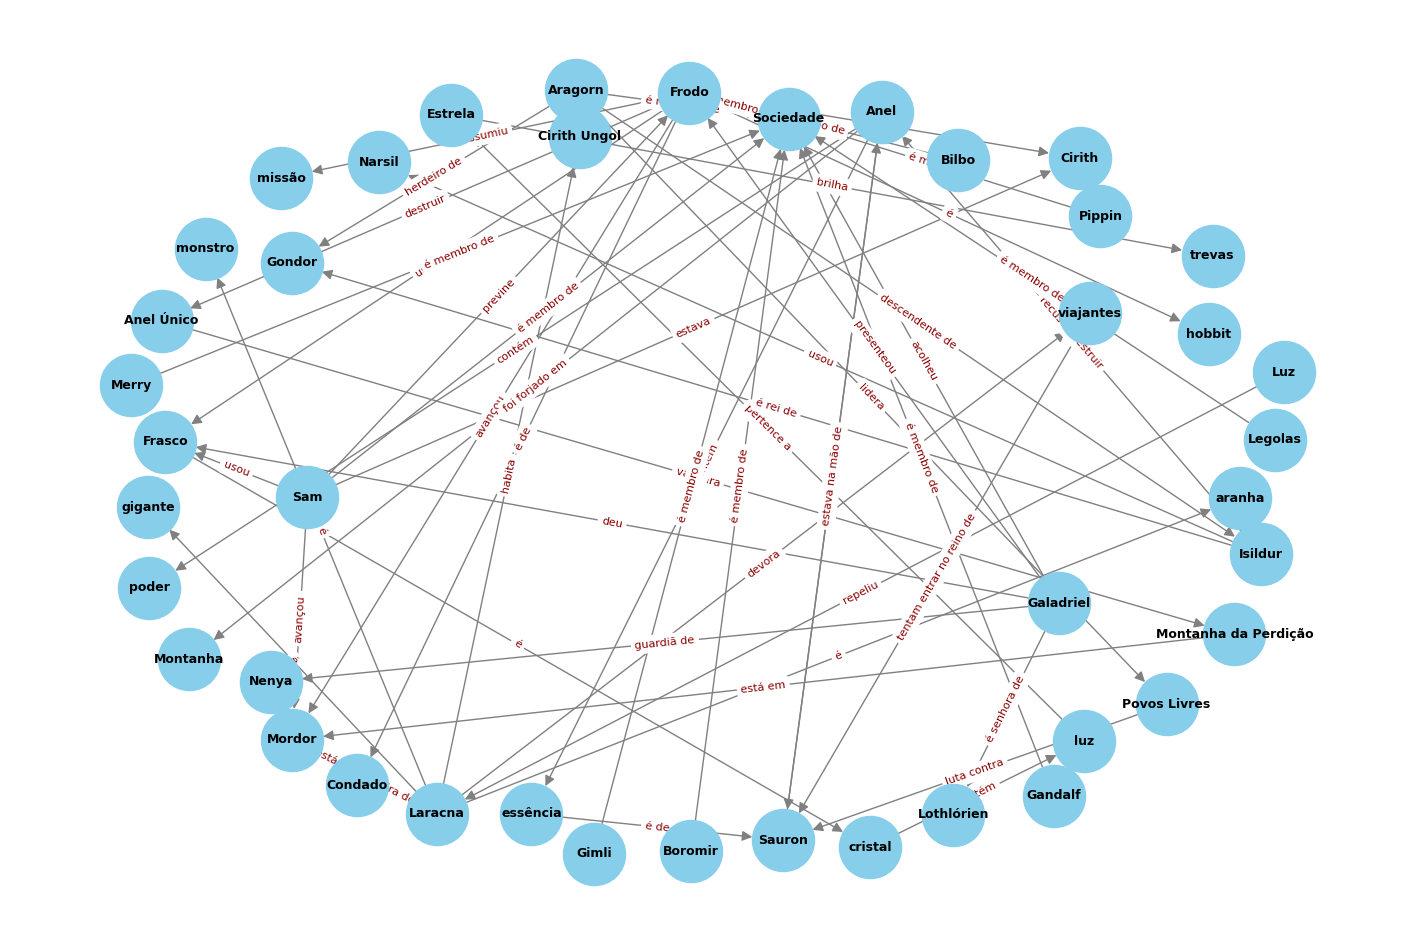

In [ ]:
desenhar_grafo(grafo)

Este é todo o conhecimento extraído dos 10 documentos, em uma única imagem. Com tantas setas o desenho fica cheio, então vamos olhar um pedaço de cada vez.

### 11.4 Dando zoom em um nó

O `ego_graph` recorta um pedaço do grafo: ele devolve um nó e tudo o que está em volta dele. O `radius=1` pega apenas os vizinhos diretos, e o `undirected=True` considera tanto as setas que saem do nó quanto as que chegam nele.

Vamos recortar a vizinhança de `Galadriel`.

> Se aparecer um erro dizendo que o nó não existe, o LLM deu outro nome a essa entidade. Troque `"Galadriel"` por um dos nomes da lista da célula 10.3.

In [ ]:
zoom = nx.ego_graph(grafo, "Galadriel", radius=1, undirected=True)

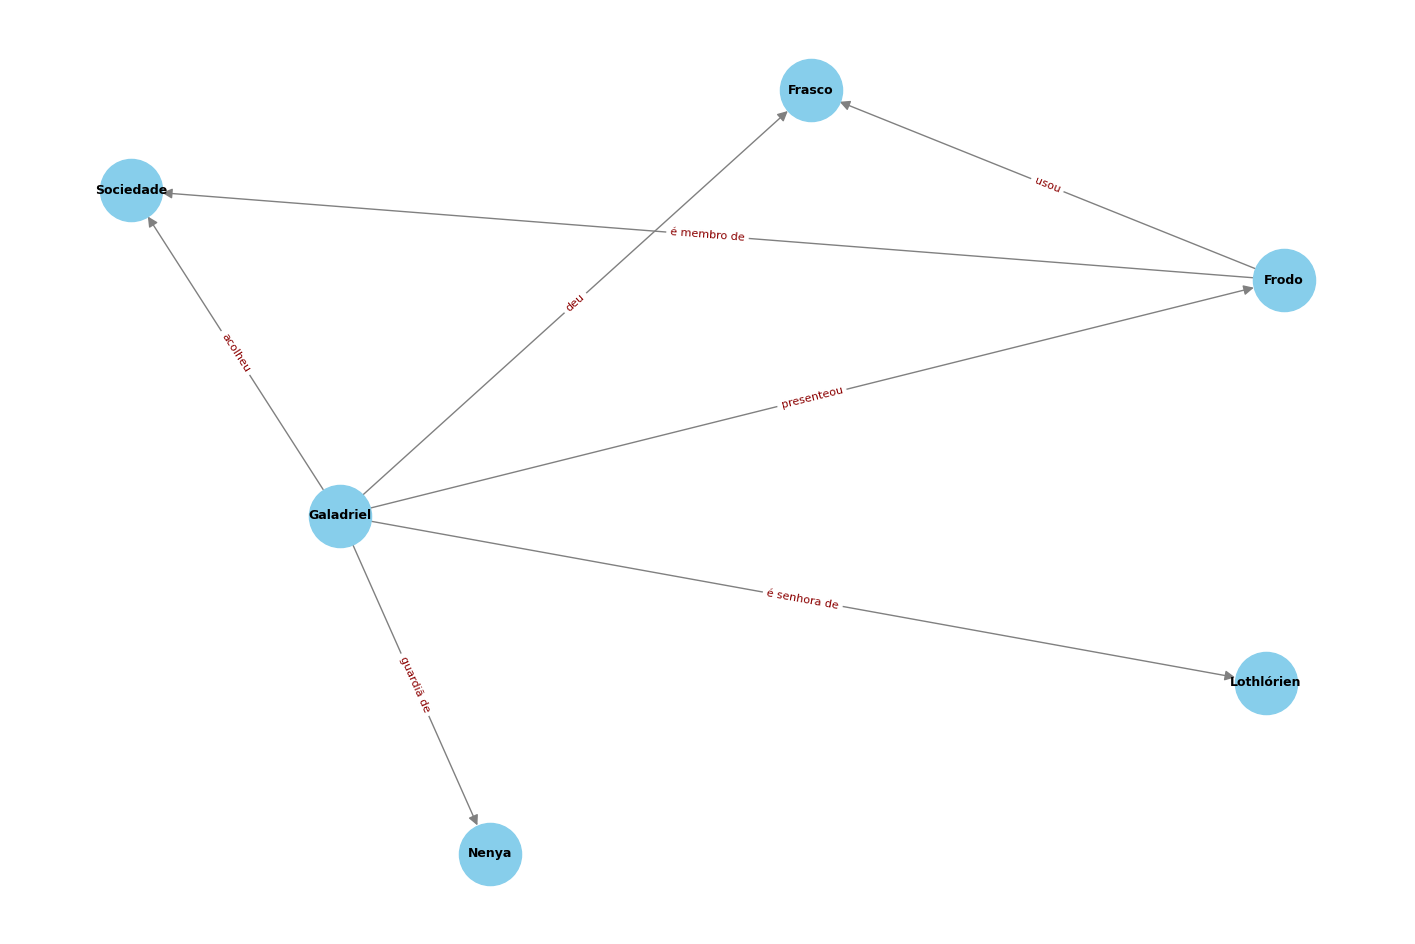

In [ ]:
desenhar_grafo(zoom)

Em volta de `Galadriel` estão fatos que vieram de **documentos diferentes**: o reino onde ela vive, o anel que ela guarda e o presente que ela deu. No grafo, tudo o que sabemos sobre ela está ligado em um só lugar.

## 🧭 Passo 12: Recuperação — caminhando pelo grafo

No RAG tradicional, recuperar era buscar os textos mais parecidos. No GraphRAG, recuperar é feito em dois movimentos:

1. **Achar os pontos de partida**: quais nós do grafo aparecem na pergunta?
2. **Caminhar pelas setas**: partindo desses nós, quais fatos estão por perto?

### 12.1 Achando os pontos de partida

Vamos comparar o nome de cada nó com a pergunta. Para a comparação não depender de letras maiúsculas, convertemos tudo para minúsculas com o `lower`.

In [ ]:
pergunta_minuscula = pergunta_dificil.lower()

In [ ]:
pergunta_minuscula

'em qual reino vive quem deu o frasco de eärendil a frodo?'

Agora percorremos todos os nós do grafo. Se o nome do nó aparece dentro da pergunta, ele é um ponto de partida.

In [ ]:
# Lista vazia que vai guardar os nós que aparecem na pergunta
nos_de_partida = []

# Repete os passos abaixo para cada nó do grafo
for no in grafo.nodes:
    # Converte o nome do nó para minúsculas
    no_minusculo = no.lower()
    # Verifica se o nome do nó aparece dentro da pergunta
    if no_minusculo in pergunta_minuscula:
        # Guarda o nó como ponto de partida
        nos_de_partida.append(no)

In [ ]:
nos_de_partida

['Frodo', 'Frasco']

Repare que `Galadriel` e `Lothlórien` não estão nessa lista, pois não aparecem na pergunta. Vamos chegar até eles caminhando.

### 12.2 Caminhando a partir de um nó

Cada seta que atravessamos é um **salto**:

- Com **1 salto**, chegamos aos vizinhos diretos do nó.
- Com **2 saltos**, chegamos também aos vizinhos dos vizinhos.

Quem faz essa caminhada é o `ego_graph`, o mesmo que usamos para dar zoom no desenho. Ele devolve um grafo menor, apenas com o que está a até `radius` saltos do nó escolhido.

O `undirected=True` permite caminhar nos dois sentidos da seta. Queremos chegar a Galadriel tanto por uma seta que **sai** dela quanto por uma que **chega** nela.

Vamos testar com o primeiro ponto de partida:

In [ ]:
primeiro_no = nos_de_partida[0]

In [ ]:
vizinhanca = nx.ego_graph(grafo, primeiro_no, radius=2, undirected=True)

Estes são os nós alcançados em até 2 saltos:

In [ ]:
list(vizinhanca.nodes)

['Frodo',
 'hobbit',
 'Condado',
 'Anel Único',
 'Bilbo',
 'missão',
 'Montanha da Perdição',
 'Mordor',
 'Sam',
 'Galadriel',
 'Lothlórien',
 'Nenya',
 'Sociedade',
 'Frasco',
 'cristal',
 'Laracna',
 'Cirith',
 'Aragorn',
 'Merry',
 'Pippin',
 'Gandalf',
 'Boromir',
 'Legolas',
 'Gimli']

### 12.3 Coletando as relações de todos os pontos de partida

Agora fazemos a caminhada a partir de **cada** ponto de partida e anotamos todas as relações encontradas.

Cada relação vira uma frase no formato `sujeito -> relação -> objeto`. Antes de guardar, verificamos se a frase já está na lista, para não repetir.

In [ ]:
# Lista vazia que vai guardar as relações encontradas
relacoes = []

# Repete os passos abaixo para cada ponto de partida
for no in nos_de_partida:
    # Caminha até 2 saltos a partir do nó
    vizinhanca = nx.ego_graph(grafo, no, radius=2, undirected=True)
    # Percorre cada aresta encontrada na caminhada
    for sujeito, objeto, dados in vizinhanca.edges(data=True):
        # Monta a frase da relação
        frase = sujeito + " -> " + dados["relacao"] + " -> " + objeto
        # Guarda a frase apenas se ela ainda não estiver na lista
        if frase not in relacoes:
            relacoes.append(frase)

Quantas relações foram recuperadas?

In [ ]:
len(relacoes)

31

### 12.4 Montando o contexto

Assim como na Parte 1, juntamos tudo em um único texto para entregar ao LLM. A diferença é que agora o contexto é feito de **relações**, e não de parágrafos.

In [ ]:
# Começa com um texto vazio
contexto_grafo = ""

# Repete os passos abaixo para cada relação
for frase in relacoes:
    # Acrescenta a relação ao contexto
    contexto_grafo = contexto_grafo + frase
    # Acrescenta uma quebra de linha para separar da próxima
    contexto_grafo = contexto_grafo + "\n"

In [ ]:
print(contexto_grafo)

Frodo -> é -> hobbit
Frodo -> é de -> Condado
Frodo -> destruir -> Anel Único
Frodo -> assumiu -> missão
Frodo -> usou -> Frasco
Frodo -> avançou -> Mordor
Frodo -> estava -> Cirith
Frodo -> é membro de -> Sociedade
Anel Único -> vai para -> Montanha da Perdição
Bilbo -> é tio de -> Frodo
Montanha da Perdição -> está em -> Mordor
Sam -> previne -> Frodo
Sam -> usou -> Frasco
Sam -> avançou -> Mordor
Sam -> estava -> Cirith
Sam -> é membro de -> Sociedade
Galadriel -> é senhora de -> Lothlórien
Galadriel -> guardiã de -> Nenya
Galadriel -> acolheu -> Sociedade
Galadriel -> presenteou -> Frodo
Galadriel -> deu -> Frasco
Frasco -> é -> cristal
Laracna -> está na fronteira de -> Mordor
Aragorn -> é membro de -> Sociedade
Merry -> é membro de -> Sociedade
Pippin -> é membro de -> Sociedade
Gandalf -> é membro de -> Sociedade
Boromir -> é membro de -> Sociedade
Legolas -> é membro de -> Sociedade
Gimli -> é membro de -> Sociedade
cristal -> contém -> luz



Procure nas linhas acima quem deu o Frasco de Eärendil e onde essa personagem vive. **Os dois fatos estão no contexto**, mesmo tendo vindo de documentos diferentes e mesmo sem a pergunta citar Galadriel.

> Nossa base é muito pequena, então 2 saltos já alcançam boa parte do grafo. Em uma base real, com milhares de nós, a caminhada seleciona apenas uma pequena região em volta das entidades da pergunta.

## 🤖 Passo 13: Geração — o LLM responde usando o grafo

### 13.1 Escrevendo o prompt

O prompt é parecido com o da Parte 1. A diferença é que explicamos ao LLM como ler as relações e pedimos que ele **conecte** umas às outras.

In [ ]:
texto_do_prompt_graphrag = """
Você é um assistente objetivo especialista em Senhor dos Anéis.
Responda à pergunta usando apenas as relações do grafo fornecidas abaixo.
Cada linha é uma relação no formato: sujeito -> relação -> objeto.
Para responder, conecte as relações entre si, seguindo as entidades que elas têm em comum.
Dê uma resposta CURTA e, em seguida, explique em uma frase quais relações você conectou.
Se a resposta não estiver nas relações, diga que não sabe.

Relações do grafo:
{contexto}

Pergunta: {pergunta}
Resposta:
"""

### 13.2 Criando o modelo de prompt

In [ ]:
prompt_graphrag = ChatPromptTemplate.from_template(texto_do_prompt_graphrag)

### 13.3 Preenchendo o prompt

In [ ]:
prompt_graphrag_preenchido = prompt_graphrag.invoke({"contexto": contexto_grafo, "pergunta": pergunta_dificil})

### 13.4 Enviando o prompt ao LLM

In [ ]:
resposta_graphrag = llm.invoke(prompt_graphrag_preenchido)

### 13.5 Lendo a resposta

In [ ]:
print(resposta_graphrag.content)

Lothlórien.  
Conectei: Galadriel → presenteou → Frodo e Galadriel → deu → Frasco, depois Galadriel → é senhora de → Lothlórien.


🎉 O GraphRAG respondeu à pergunta que o RAG tradicional não conseguiu, e ainda explicou o caminho que percorreu.

## 🧩 Passo 14: Juntando tudo em uma função

Assim como fizemos com o `executar_rag`, vamos reunir a recuperação (Passo 12) e a geração (Passo 13) em uma função.

A extração das triplas e a montagem do grafo ficam **fora** da função, porque fazem parte da indexação e só precisam acontecer uma vez.

As linhas são exatamente as mesmas que executamos acima.

In [ ]:
def executar_graphrag(pergunta=None):
    # Se não recebeu uma pergunta, pede pelo input
    if pergunta is None:
        pergunta = input("Digite sua pergunta: ")

    # Recuperação: acha os nós do grafo que aparecem na pergunta
    pergunta_minuscula = pergunta.lower()
    nos_de_partida = []
    for no in grafo.nodes:
        no_minusculo = no.lower()
        if no_minusculo in pergunta_minuscula:
            nos_de_partida.append(no)

    # Recuperação: caminha até 2 saltos a partir de cada nó e coleta as relações
    relacoes = []
    for no in nos_de_partida:
        vizinhanca = nx.ego_graph(grafo, no, radius=2, undirected=True)
        for sujeito, objeto, dados in vizinhanca.edges(data=True):
            frase = sujeito + " -> " + dados["relacao"] + " -> " + objeto
            if frase not in relacoes:
                relacoes.append(frase)

    # Junta as relações em um único contexto
    contexto_grafo = ""
    for frase in relacoes:
        contexto_grafo = contexto_grafo + frase
        contexto_grafo = contexto_grafo + "\n"

    # Preenche o prompt com o contexto e a pergunta
    prompt_preenchido = prompt_graphrag.invoke({"contexto": contexto_grafo, "pergunta": pergunta})

    # Geração: envia o prompt ao LLM
    resposta = llm.invoke(prompt_preenchido)

    # Exibe os pontos de partida, a quantidade de relações e a resposta
    print()
    print("🧭 PONTOS DE PARTIDA NO GRAFO:", nos_de_partida)
    print("🕸️ RELAÇÕES RECUPERADAS:", len(relacoes))
    print()
    print("🤖 RESPOSTA:")
    print(resposta.content)

## ⚔️ Passo 15: RAG tradicional vs GraphRAG

Vamos fazer a **mesma pergunta** para os dois e comparar.

### 15.1 RAG tradicional

In [ ]:
executar_rag(pergunta_dificil)


🤖 RESPOSTA:
Lothlórien.


### 15.2 GraphRAG

In [ ]:
executar_graphrag(pergunta_dificil)


🧭 PONTOS DE PARTIDA NO GRAFO: ['Frodo', 'Frasco']
🕸️ RELAÇÕES RECUPERADAS: 31

🤖 RESPOSTA:
Lothlórien.  
Conectei: Galadriel → presenteou → Frodo e Galadriel → deu → Frasco, depois Galadriel → é senhora de → Lothlórien.


A pergunta é a mesma, os documentos são os mesmos e o LLM é o mesmo. O que mudou foi a forma de **guardar** e de **buscar** a informação:

- O RAG tradicional procurou textos parecidos com a pergunta e não encontrou o que falava de Lothlórien.
- O GraphRAG partiu de `Frodo` e do `Frasco de Eärendil`, caminhou até `Galadriel` e, dela, chegou a `Lothlórien`.

### 15.3 Faça a sua pergunta

Execute a célula abaixo e digite uma pergunta. Algumas sugestões que também exigem cruzar documentos:

> Qual membro da Sociedade do Anel é descendente de Isildur?

> Qual criatura foi repelida com o presente que Galadriel deu a Frodo?

Escreva o nome das entidades como elas aparecem no grafo (por exemplo, `Frodo` e `Galadriel`). É por esses nomes que a busca encontra os pontos de partida.

In [ ]:
executar_graphrag()

Digite sua pergunta: qual presente deu galadriel para frodo

🧭 PONTOS DE PARTIDA NO GRAFO: ['Frodo', 'Galadriel']
🕸️ RELAÇÕES RECUPERADAS: 30

🤖 RESPOSTA:
Galadriel deu a Frodo o Frasco (um cristal).  
Conectei “Galadriel → presenteou → Frodo” com “Galadriel → deu → Frasco” e “Frasco → é → cristal”.


## 💡 Conclusão: prós e contras do GraphRAG

### O que construímos

| Etapa | O que fizemos | Código principal |
| :--- | :--- | :--- |
| **Indexação** | O LLM extraiu as triplas dos 10 textos e montamos o grafo | `grafo.add_edge(sujeito, objeto, relacao=relacao)` |
| **Recuperação** | Achamos os nós da pergunta e caminhamos 2 saltos | `nx.ego_graph(grafo, no, radius=2, undirected=True)` |
| **Geração** | O LLM respondeu conectando as relações | `llm.invoke(prompt_preenchido)` |

### ✅ Prós

- **Conecta informações espalhadas.** Responde perguntas que exigem cruzar vários documentos, mesmo quando a pergunta não cita o elo entre eles.
- **É explicável.** Dá para ver o caminho percorrido no grafo e entender de onde a resposta saiu.
- **Contexto enxuto.** O LLM recebe fatos diretos, e não parágrafos inteiros.
- **Podemos olhar para o conhecimento.** O desenho do grafo mostra o que a base sabe e ajuda a encontrar erros.

### ❌ Contras

- **Indexação mais cara e mais lenta.** Foi preciso uma chamada ao LLM para **cada** documento. No RAG tradicional, bastou gerar os embeddings. Em uma base com milhares de documentos, essa diferença pesa no custo e no tempo.
- **A qualidade depende da extração.** Se o LLM deixar um fato de fora ou extrair uma tripla errada, o grafo fica incompleto ou errado, e a resposta também.
- **Nomes duplicados quebram as conexões.** Se a mesma entidade aparecer como `Frodo` e como `Frodo Bolseiro`, viram dois nós separados. Em projetos reais existe uma etapa só para unificar esses nomes.
- **Perde detalhes do texto.** Uma tripla guarda o fato, mas não o tom nem as explicações do texto original.
- **Mais complexo de construir e manter.** Há mais etapas, mais código e mais pontos que podem falhar. Quando um documento muda, é preciso extrair as triplas dele de novo.
- **Nossa busca é simples.** Ela só encontra um ponto de partida quando o nome do nó aparece escrito na pergunta. Sistemas reais usam embeddings também nessa etapa.

### Quando usar cada um?

| Situação | Melhor escolha |
| :--- | :--- |
| A resposta está em um único trecho ("Quem é Frodo?") | **RAG tradicional** |
| É preciso cruzar informações de vários documentos | **GraphRAG** |
| Os dados são cheios de ligações (pessoas, empresas, leis, linhagens) | **GraphRAG** |
| A base é grande e muda com frequência | **RAG tradicional** |
| É preciso mostrar o caminho que levou à resposta | **GraphRAG** |
| Há pouco tempo e pouco orçamento | **RAG tradicional** |

Na prática, muitos sistemas usam os **dois juntos**: a busca vetorial encontra os pontos de partida e o grafo conecta os fatos em volta deles.

### Para experimentar

- Faça ao `executar_graphrag` uma pergunta sem o nome de nenhuma entidade do grafo. O que aparece em "pontos de partida"?
- Compare as triplas do Passo 9.5 com os textos originais. O LLM deixou algum fato de fora?